### Assumptions

As with Pearson correlation (r), there are some assumptions concerning valid ANOVAs and t-tests:
- Normal distribution of the numeric variable for each group of the categorical variable 
- Equal variance of the numeric variable for each group of the categorical variable (note: variance = sqrt of std)
    - Note: if the sample size across the groups are close to equal, then this assumption is less important
- The data used to carry out the analyses were sampled independently between the groups
    - i. e. The data were randomly sampled across all possible group values. e.g. You didn't go to a women's conference to collect female samples and then a men's organization to collect male samples.
    - Note: if the group sample sizes are unequal, and variances are unequal, then use Welch's t-test.
 
t = (x1 - x2) / sqrt((s1^2)/n1 + (s2^2)/n2)

### ANOVA

Some categorical features will have 3 or many more groups. We could use a t-test to compare all pairs of groups of that categorical feature against some numeric label. But it makes more sense to use a measure that indicates whether there is a significant difference in means across all of the groups at onece. This is the purpose of an **analysis of variance (ANOVA)**, which refers to a collection of statistical models and their associated estimation procedures (e.g., the *variation* among categorical groups) used to analyze the differences among group means in a sample.

A *one-way* ANOVA is a certain type (the most simple) that is based on analyzing a bivariate relationship wih one categorical feature and one numeric label. Therefore, a one-way ANOVA will tell you whether there is a general difference across all groups (even if there are 3 or more) of that categorical feature. Other versions of ANOVA can test the effects of many categorical and numeric features at once on either one or many labels. 

In [183]:
from scipy import stats
from statsmodels.stats.multicomp import MultiComparison
import statistics as stat
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.simplefilter("ignore")

edu_PartialHighSchool = [30000, 10000, 10000, 20000, 70000, 30000, 10000, 20000, 10000, 30000]
edu_HighSchool = [20000, 30000, 60000, 20000, 40000, 60000, 60000]
edu_PartialCollege = [60000, 40000, 30000, 130000, 60000, 40000]
edu_Bachelors = [40000, 20000, 90000, 120000, 60000, 130000, 20000, 100000, 80000, 30000, 100000, 120000]
edu_Graduate = [160000, 50000, 80000, 30000, 40000, 80000, 130000, 100000, 130000, 50000, 130000]

print(f"Partial High School: \t{int(stat.mean(edu_PartialHighSchool))}")
print(f"High School: \t\t{int(stat.mean(edu_HighSchool))}")
print(f"Partial College: \t{int(stat.mean(edu_PartialCollege))}")
print(f"Bachelors: \t\t{int(stat.mean(edu_Bachelors))}")
print(f"Graduate: \t\t{int(stat.mean(edu_Graduate))}")

Partial High School: 	24000
High School: 		41428
Partial College: 	60000
Bachelors: 		75833
Graduate: 		89090


In [33]:
t, p = stats.ttest_ind(edu_PartialHighSchool, edu_HighSchool)

print(f"t-value: {t}\np-value: {p}")

t-value: -1.9131753750607223
p-value: 0.07500898731578687


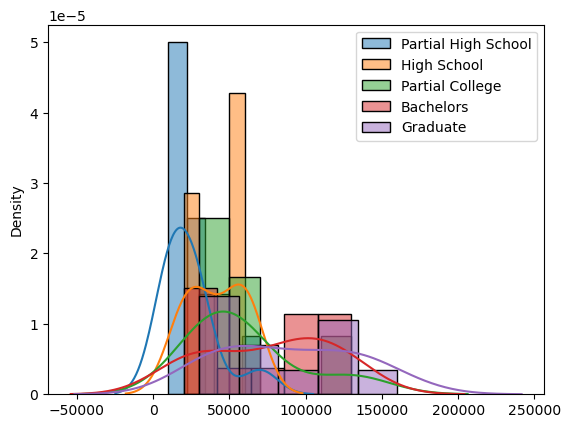

In [35]:
sns.histplot(edu_PartialHighSchool, label="Partial High School", kde=True, stat="density", kde_kws=dict(cut=3))
sns.histplot(edu_HighSchool, label="High School", kde=True, stat="density", kde_kws=dict(cut=3))
sns.histplot(edu_PartialCollege, label="Partial College", kde=True, stat="density", kde_kws=dict(cut=3))
sns.histplot(edu_Bachelors, label="Bachelors", kde=True, stat="density", kde_kws=dict(cut=3))
sns.histplot(edu_Graduate, label="Graduate", kde=True, stat="density", kde_kws=dict(cut=3))
plt.legend()
plt.show()

In [36]:
f, p = stats.f_oneway(edu_PartialHighSchool, edu_Bachelors, edu_Graduate, edu_HighSchool, edu_PartialCollege)

print(f"f-value: {f}\np-value: {p}")

f-value: 5.778065095961635
p-value: 0.0008781084858501968


In [39]:
df = pd.read_csv("data/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


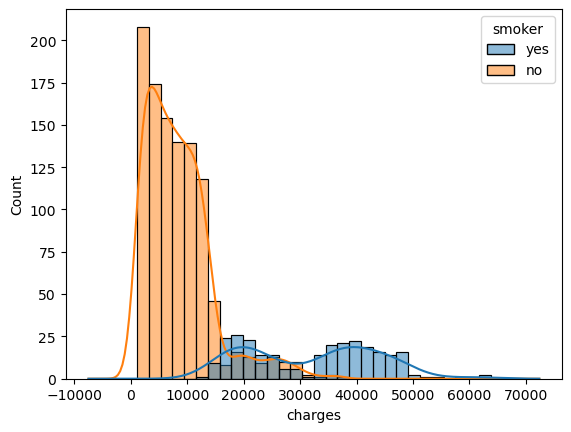

In [41]:
sns.histplot(data=df, x="charges", hue="smoker", kde=True, kde_kws=dict(cut=3));

In [43]:
smoker_y = df[df["smoker"] == "yes"]
smoker_n = df[df["smoker"] == "no"]

stats.ttest_ind(smoker_y["charges"], smoker_n["charges"])

TtestResult(statistic=46.66492117272371, pvalue=8.271435842179102e-283, df=1336.0)

In [45]:
feature = "smoker"
label = "charges"

groups = df[feature].unique()
grouped_values = []
for group in groups:
    grouped_values.append(df[df[feature] == group][label])

stats.f_oneway(*grouped_values) # * makes it like f_oneway(list1, list2), it separates different list members

F_onewayResult(statistic=2177.614868056519, pvalue=8.271435842182967e-283)

In [47]:
def anova(feature, label):
    groups = df[feature].unique()
    grouped_values = []
    for group in groups:
        grouped_values.append(df[df[feature] == group][label])

    return stats.f_oneway(*grouped_values)

In [49]:
anova("region", "charges")

F_onewayResult(statistic=2.96962669358912, pvalue=0.0308933560705201)

In [51]:
df = pd.read_csv("data/bike_buyers.csv")
df

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes
997,11809,Married,NaN,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No


In [53]:
df.Education.unique()

array(['Bachelors', 'Partial College', 'High School',
       'Partial High School', 'Graduate Degree'], dtype=object)

In [55]:
df["Education_rank"] = df["Education"]
df.Education_rank.replace(["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"], 
                         [1, 2, 3, 4, 5], inplace=True)

df

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike,Education_rank
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No,4
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No,3
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No,3
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes,4
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes,2
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes,5
997,11809,Married,NaN,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes,4
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No,4


In [57]:
df["Commute_rank"] = df["Commute Distance"]
df.Commute_rank.replace(["0-1 Miles", "1-2 Miles", "2-5 Miles", "5-10 Miles", "10+ Miles"],
                       [0, 1, 2, 5, 10], inplace=True)
df

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike,Education_rank,Commute_rank
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No,4,0
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No,3,0
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No,3,2
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes,4,5
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes,2,2
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes,5,2
997,11809,Married,NaN,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes,4,0
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No,4,1


In [93]:
df = pd.read_csv("data/bike_buyers.csv")

In [95]:
def clean_bikebuyers(df):
    df["Education_rank"] = df["Education"]
    df["Commute_rank"] = df["Commute Distance"]
    df["Purchased_bike"] = df["Purchased Bike"]

    df.Education_rank.replace(["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"], 
                         [1, 2, 3, 4, 5], inplace=True)
    df.Commute_rank.replace(["0-1 Miles", "1-2 Miles", "2-5 Miles", "5-10 Miles", "10+ Miles"],
                       [0, 1, 2, 5, 10], inplace=True)
    df.Purchased_bike.replace(["Yes", "No"],
                       [1, 0], inplace=True)

    df.astype({"Education_rank": "int64"})
    df.astype({"Commute_rank": "int64"})
    df.astype({"Purchased_bike": "int64"})

    return df

In [97]:
df = clean_bikebuyers(df)
df

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike,Education_rank,Commute_rank,Purchased_bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No,4,0,0
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No,3,0,0
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No,3,2,0
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes,4,5,1
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes,4,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes,2,2,1
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes,5,2,1
997,11809,Married,NaN,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes,4,0,1
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No,4,1,0


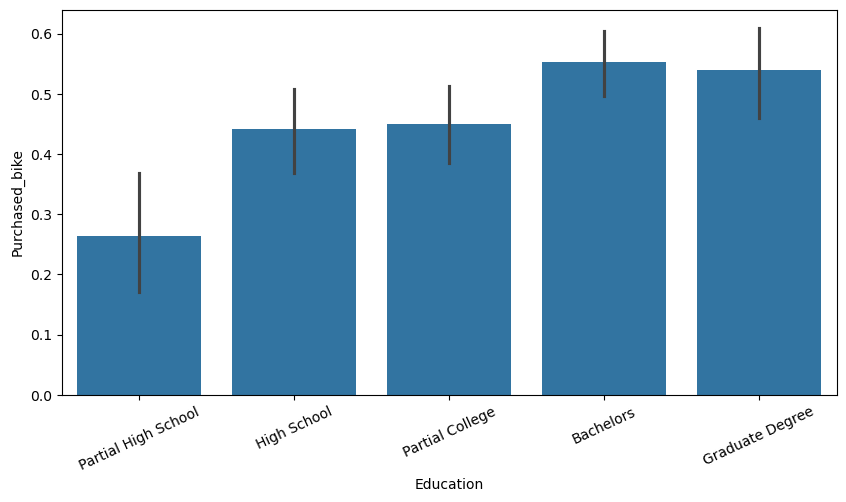

In [109]:
plt.figure(figsize=(10, 5))
viz = sns.barplot(x=df.Education, y=df.Purchased_bike, 
                  order=["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"]);
viz.set_xticklabels(viz.get_xticklabels(), rotation=25);

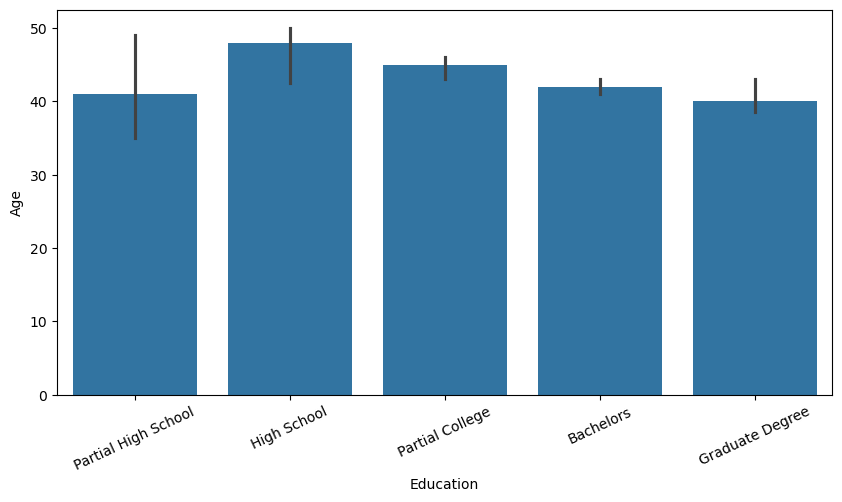

In [115]:
plt.figure(figsize=(10, 5))
viz = sns.barplot(x=df.Education, y=df.Age, estimator=np.median, 
                  order=["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"]);
viz.set_xticklabels(viz.get_xticklabels(), rotation=25);

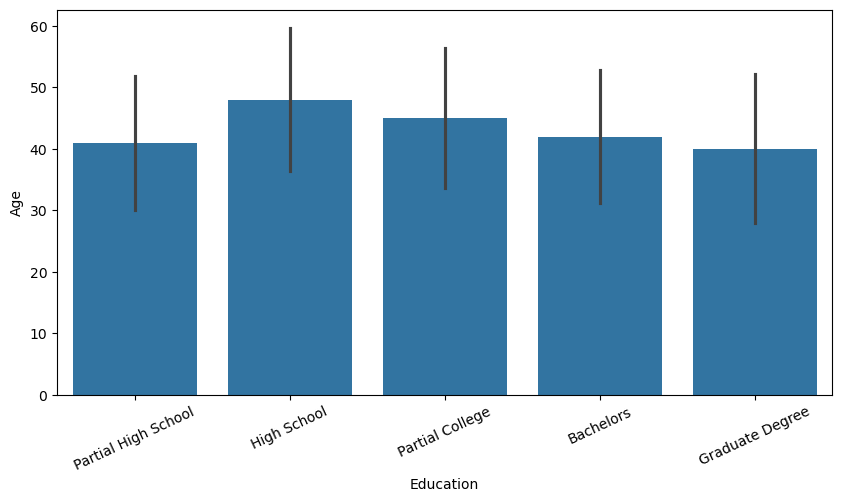

In [117]:
plt.figure(figsize=(10, 5))
viz = sns.barplot(x=df.Education, y=df.Age, estimator=np.median, ci="sd", # ANOVA and t-test assumes that equal variances acroos groups
                  order=["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"]);
viz.set_xticklabels(viz.get_xticklabels(), rotation=25);

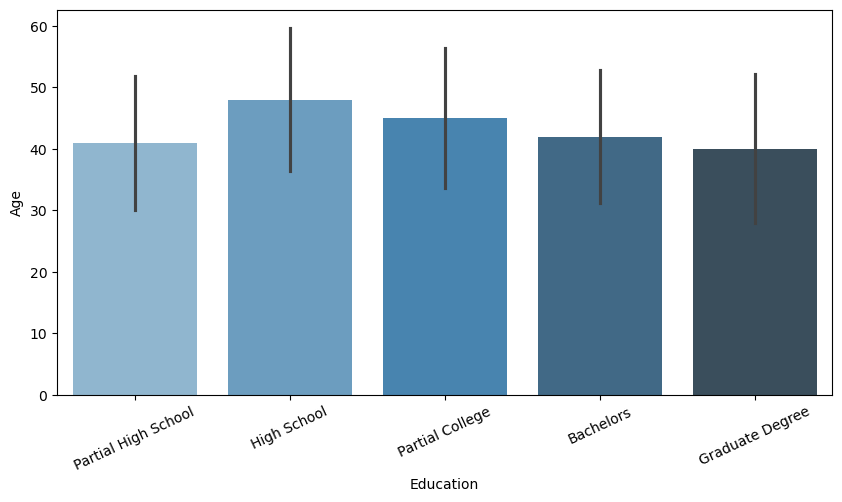

In [119]:
plt.figure(figsize=(10, 5))
viz = sns.barplot(x=df.Education, y=df.Age, estimator=np.median, ci="sd", palette="Blues_d",
                  order=["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"]);
viz.set_xticklabels(viz.get_xticklabels(), rotation=25);

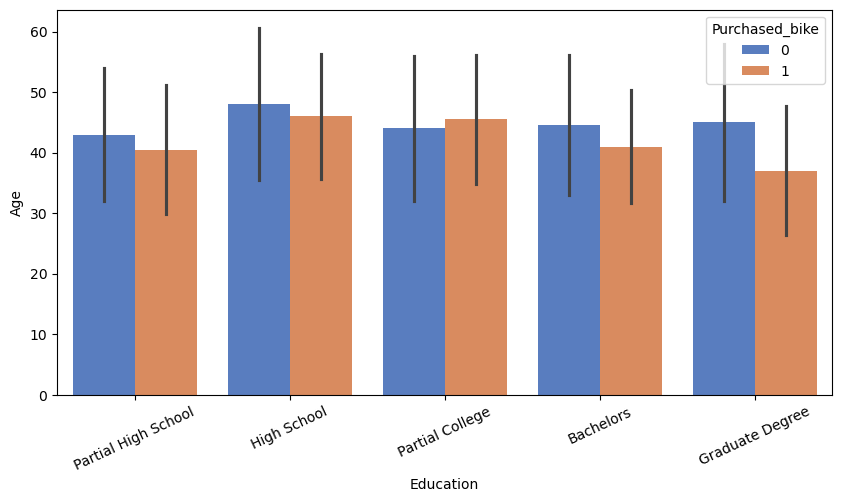

In [145]:
plt.figure(figsize=(10, 5))
viz = sns.barplot(x=df.Education, y=df.Age, hue=df.Purchased_bike, estimator=np.median, ci="sd", palette="muted",
                  order=["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"]);
viz.set_xticklabels(viz.get_xticklabels(), rotation=25);

<Figure size 1000x500 with 0 Axes>

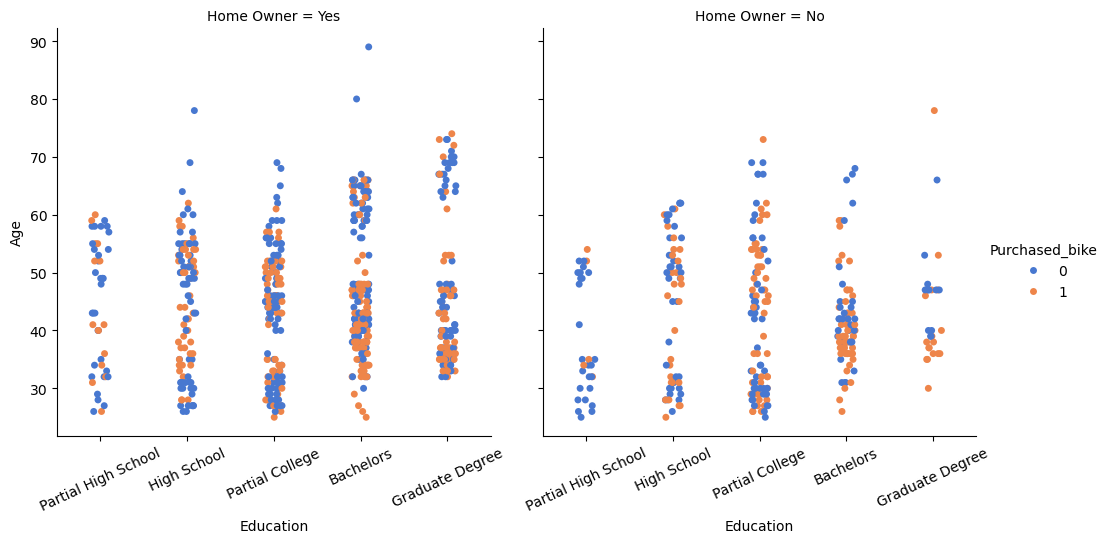

In [147]:
plt.figure(figsize=(10, 5))
viz = sns.catplot(data=df, x="Education", y="Age", hue="Purchased_bike", col="Home Owner", estimator=np.median, ci="sd", palette="muted",
                  order=["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"]);
viz.set_xticklabels(rotation=25);

<Figure size 1000x500 with 0 Axes>

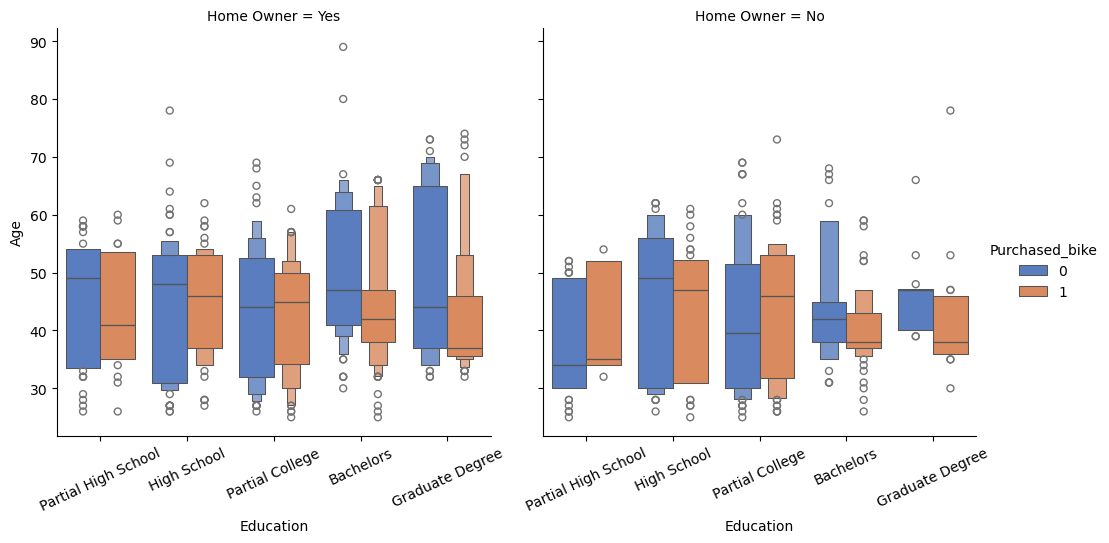

In [149]:
plt.figure(figsize=(10, 5))
viz = sns.catplot(data=df, x="Education", y="Age", hue="Purchased_bike", col="Home Owner", estimator=np.median, ci="sd", palette="muted", kind="boxen",
                  order=["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"]);
viz.set_xticklabels(rotation=25);

<Figure size 1000x500 with 0 Axes>

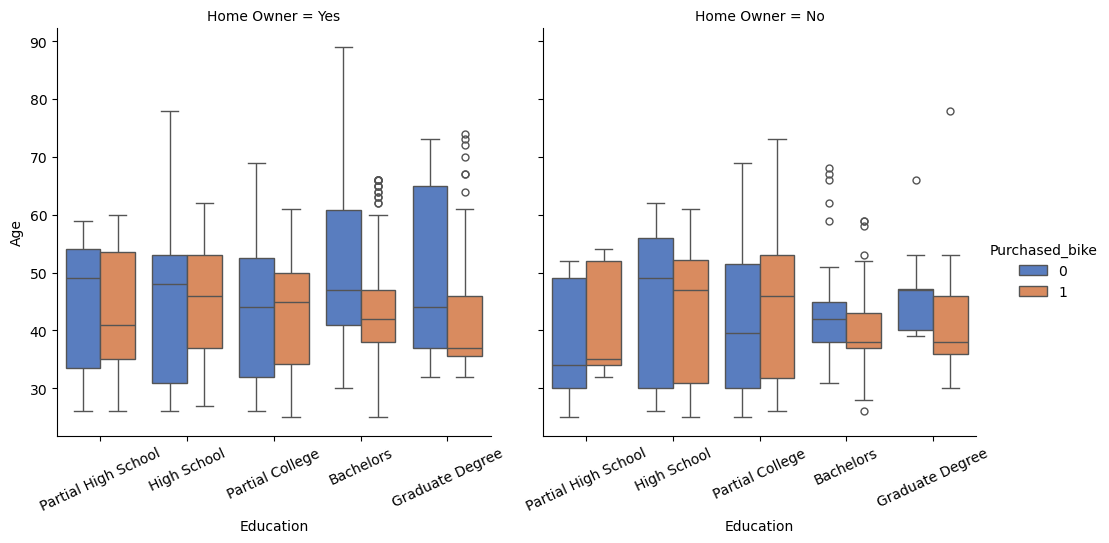

In [151]:
plt.figure(figsize=(10, 5))
viz = sns.catplot(data=df, x="Education", y="Age", hue="Purchased_bike", col="Home Owner", estimator=np.median, ci="sd", palette="muted", kind="box",
                  order=["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"]);
viz.set_xticklabels(rotation=25);

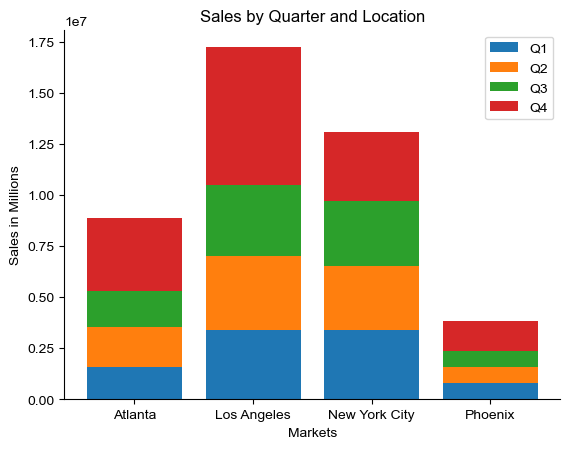

In [157]:
df1 = pd.DataFrame({"Locations": ["Atlanta", "Los Angeles", "New York City", "Phoenix"],
                   "Q1 Sales": [1567811, 3391023, 3409871, 789123],
                   "Q2 Sales": [1981237, 3609877, 3100098, 810988],
                   "Q3 Sales": [1761231, 3509889, 3209876, 751233],
                   "Q4 Sales": [3578900, 6712333, 3378900, 1500092]})

# Positions fot the bars
x = np.arange(len(df1.Locations))

# Store the four columns from the DataFrame and "flatten" them to appear as a regular Python list structure
list_1 = df1["Q1 Sales"].values.flatten()
list_2 = df1["Q2 Sales"].values.flatten()
list_3 = df1["Q3 Sales"].values.flatten()
list_4 = df1["Q4 Sales"].values.flatten()

# Plot the bar charts
plt.bar(x, list_1, label="Q1")
plt.bar(x, list_2, bottom=list_1, label="Q2")
plt.bar(x, list_3, bottom=list_1+list_2, label="Q3")
plt.bar(x, list_4, bottom=list_1+list_2+list_3, label="Q4")

# Plot the Pokemon names as the x ticks
plt.xticks(x, df1.Locations)

# Legend
plt.legend(loc="upper right")

# Labels and Titles
plt.title("Sales by Quarter and Location")
plt.xlabel("Markets")
plt.ylabel("Sales in Millions")

# Add an SNS style and increase figure size
sns.set_style("white")
sns.set_context({"figure.figsize": (4, 6)})
sns.despine(top=True, right=True);

In [177]:
groups = df.Education.unique()
group_labels = []
for g in groups:
    group_labels.append(df[df.Education == g]["Purchased_bike"])

f, p = stats.f_oneway(*group_labels)

print(f"f: {f:.4}\np: {p:.4}")

f: 6.465
p: 3.888e-05


In [163]:
r, p = stats.pearsonr(df.Education_rank, df.Purchased_bike)

print(f"r: {r:.4}\np: {p:.4}")

r: 0.1408
p: 7.901e-06


In [179]:
partial_hs = df[df.Education == "Partial High School"]
high_school = df[df.Education == "High School"]
t, p = stats.ttest_ind(partial_hs.Purchased_bike, high_school.Purchased_bike)

print(f"t: {t:.4}\np: {p:.4}")

t: -2.698
p: 0.007445


### Tukey Model for correction

In [186]:
mc = MultiComparison(df.Purchased_bike, df.Education)
print(mc.tukeyhsd())

           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
     group1            group2       meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
      Bachelors     Graduate Degree  -0.0121  0.999 -0.1404  0.1163  False
      Bachelors         High School  -0.1109 0.1204 -0.2381  0.0162  False
      Bachelors     Partial College  -0.1032 0.0942 -0.2166  0.0102  False
      Bachelors Partial High School  -0.2891 0.0001 -0.4623 -0.1159   True
Graduate Degree         High School  -0.0989 0.3297 -0.2428   0.045  False
Graduate Degree     Partial College  -0.0912 0.3236  -0.223  0.0407  False
Graduate Degree Partial High School  -0.2771 0.0005 -0.4629 -0.0913   True
    High School     Partial College   0.0077 0.9998  -0.123  0.1385  False
    High School Partial High School  -0.1782 0.0655 -0.3632  0.0068  False
Partial College Partial High School  -0.1859 0.0322 -0.3617 -0.0101   True
-------------------------

### Bonferroni for correction

In [217]:
e_types = df.Education.unique()
ttests = []

for i, e in enumerate(e_types):
    for i2, e2 in enumerate(e_types):
        if i2 > i:
            #if i2 != len(e_types)-1:
            g1 = df[df.Education == e]["Purchased_bike"]
            g2 = df[df.Education == e2]["Purchased_bike"]
            t, p = stats.ttest_ind(g1, g2)

            ttests.append([f"{e} - {e2}: ", t.round(4), p.round(4)])

#print(*ttests, sep="\n")

threshold = 0.05 / len(ttests)

for t in ttests:
    if t[2] <= threshold:
         print(t)

['Bachelors - Partial High School: ', 4.6253, 0.0]
['Partial College - Partial High School: ', 2.9354, 0.0036]
['Partial High School - Graduate Degree: ', -4.1685, 0.0]


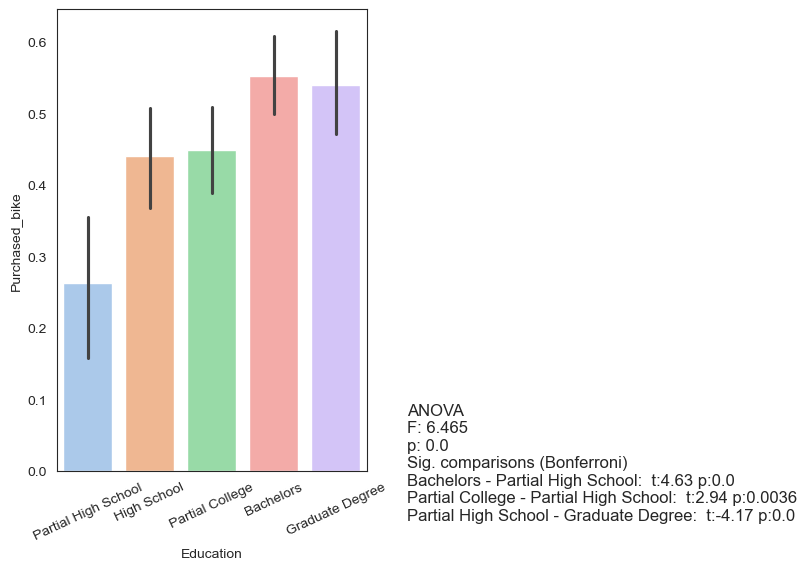

In [223]:
groups = df.Education.unique()
group_labels = []
for g in groups:
    group_labels.append(df[df.Education == g]["Purchased_bike"])
    
f, p = stats.f_oneway(*group_labels)

textstr = "ANOVA\n"
textstr += f"F: {f.round(3)}\n"
textstr += f"p: {p.round(3)}\n"
textstr += "Sig. comparisons (Bonferroni)\n"

threshold = 0.05 / len(ttests)

for t in ttests:
    if t[2] <= threshold:
         textstr += f"{t[0]} t:{t[1]:.3} p:{t[2]:.3}\n"

viz = sns.barplot(x=df.Education, y=df.Purchased_bike, palette="pastel",
                  order=["Partial High School", "High School", "Partial College", "Bachelors", "Graduate Degree"]);
viz.set_xticklabels(viz.get_xticklabels(), rotation=25);
plt.text(1, 0, textstr, fontsize=12, transform=plt.gcf().transFigure);